In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 5.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 61.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 53.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner='kgord23', repo_name='ML_hw_02_IEEE-CIS', mlflow=True)
mlflow.set_experiment("LogisticRegression_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ac71406b-c327-4ae3-bcfc-f6d33e7c46e5&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=00221f3eef3710e29acc2c3d5ff100417cc076b5798c90f5ab36f111fd81d65e




Accessing as kgord23

Initialized MLflow to track repo "kgord23/ML_hw_02_IEEE-CIS"

Repository kgord23/ML_hw_02_IEEE-CIS initialized!

<Experiment: artifact_location='mlflow-artifacts:/57ef3f82983a4230bdf34d32dacd9fb9', creation_time=1777543470912, experiment_id='0', last_update_time=1777543470912, lifecycle_stage='active', name='LogisticRegression_Training', tags={}, trace_location=None, workspace='default'>

<h1>Data Loading</h1>

In [5]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pp
import seaborn as sns
!pip install scorecardpy --quiet
import scorecardpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
train_transaction= pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
train_transaction.shape, train_identity.shape


((590540, 394), (144233, 41))

In [10]:
train_transaction.head(), train_identity.head()


(   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
 0        2987000        0          86400            68.5         W  13926   
 1        2987001        0          86401            29.0         W   2755   
 2        2987002        0          86469            59.0         W   4663   
 3        2987003        0          86499            50.0         W  18132   
 4        2987004        0          86506            50.0         H   4497   
 
    card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
 0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   
 
   V336  V337  V338  V339  
 0  NaN   NaN   NaN   NaN  
 1  

In [6]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [12]:
train.shape

(590540, 434)

In [16]:
from sklearn.model_selection import train_test_split

X=train.drop(columns='isFraud')
Y=train['isFraud']

X_train, X_val, Y_train, Y_val= train_test_split(X,Y, test_size=0.2, random_state=42)
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()


In [95]:
X_train.shape, X_val.shape


((472432, 433), (118108, 433))

In [15]:
X_train.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
5307,2992307,174911,59.000,W,4988,334.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191582,3178582,4301977,23.378,C,3867,296.0,185.0,visa,226.0,credit,...,chrome 63.0,NaN,NaN,NaN,F,F,T,F,desktop,NaN
260168,3247168,6229929,35.950,W,12577,268.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18516,3005516,497176,100.000,R,6019,583.0,150.0,visa,226.0,credit,...,chrome 62.0,24.0,1600x900,match_status:2,T,F,T,F,desktop,Windows
47538,3034538,1124702,75.000,H,16075,514.0,150.0,mastercard,102.0,credit,...,chrome 62.0 for android,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SM-G950U Build/NRD90M


<h1>Cleaning</h1>

In [7]:
X_train.isna().sum().sort_values(ascending=False)

id_24    468621
id_25    468318
id_08    468298
id_07    468298
id_21    468294
          ...  
C7            0
C14           0
C13           0
C12           0
C11           0
Length: 433, dtype: int64

In [8]:
missing_percent = X_train.isna().mean()* 100
missing_percent.sort_values(ascending=False)

id_24    99.193323
id_25    99.129187
id_08    99.124953
id_07    99.124953
id_21    99.124107
           ...    
C7        0.000000
C14       0.000000
C13       0.000000
C12       0.000000
C11       0.000000
Length: 433, dtype: float64

In [9]:
missing_percent.describe()

count    433.000000
mean      45.178239
std       36.533043
min        0.000000
25%        0.267340
50%       47.283207
75%       77.935872
max       99.193323
dtype: float64

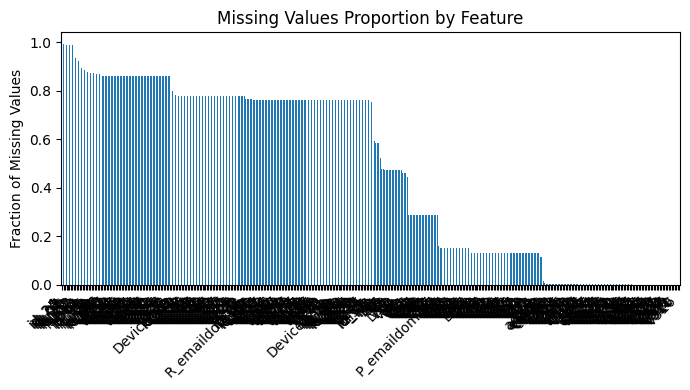

In [99]:
import matplotlib.pyplot as pp

missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

pp.figure(figsize=(7, 4))
missing_frac.plot(kind='bar')
pp.title('Missing Values Proportion by Feature')
pp.ylabel('Fraction of Missing Values')
pp.xticks(rotation=45, ha='right')
pp.tight_layout()
pp.show()

In [ ]:
threshold=0.80
cols_to_drop = missing_frac[missing_frac>threshold].index
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [28]:
!pip install scorecardpy --quiet
import scorecardpy as sc
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from category_encoders.woe import WOEEncoder

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
class NULLDropperThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold=threshold
        
    def fit(self, X, y=None):
        missing_frac=X.isna().mean()
        self.cols_to_drop=missing_frac[missing_frac>self.threshold].index.tolist()
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

In [79]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype=='object']
num_cols=[col for col in X_train.columns if X_train[col].dtype!='object']

In [ ]:
median=X_train[num_cols].median()
X_train[num_cols]=X_train[num_cols].fillna(median)
X_val[num_cols]=X_val[num_cols].fillna(median)

mode=X_train[cat_cols].mode().iloc[0]
X_train[cat_cols]=X_train[cat_cols].fillna(mode)
X_val[cat_cols]=X_val[cat_cols].fillna(mode)


In [8]:
class NULLFiller(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        self.median=X[num_cols].median()
        self.mode=X[cat_cols].mode().iloc[0]
        return self

    def transform (self, X):
        X=X.copy()
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        X[num_cols]=X[num_cols].fillna(self.median)
        X[cat_cols]=X[cat_cols].fillna(self.mode)
        return X
        
    

In [63]:
with mlflow.start_run(run_name="LogisticRegression_Cleaning"):
    mlflow.log_param("null_threshold", 0.8)
    mlflow.log_param("filling_numeric", "median")
    mlflow.log_param("filling_cat", "mode")
    mlflow.log_metric("remaining_features", X_train.shape[1])
    mlflow.log_metric("remaining_rows", X_train.shape[0])

🏃 View run LogisticRegression_Cleaning at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/8dcc1045ef5e4b2f868bbc38219a577e
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


<h1>Feature Engineering</h1>

In [9]:
class NewColsAdd(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.email_freq=X['P_emaildomain'].value_counts()
        self.card_freqs={}
        for col in ['card1', 'card2', 'addr1']:
            self.card_freqs[col]=X[col].value_counts()
        X_tmp=X.copy()
        X_tmp['card_det']=X_tmp['card1'].astype(str) + '_' + X_tmp['card2'].astype(str) + '_' + X_tmp['addr1'].astype(str)
        self.card_det_freq=X_tmp['card_det'].value_counts()
        return self

    def transform(self, X):
        X=X.copy()
        X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
        X['Transaction_hour'] = ((X['TransactionDT'] / 3600) % 24).astype(int)
        X['Transaction_day'] = ((X['TransactionDT'] / (3600 * 24)) % 7).astype(int)
        X['P_emaildomain_freq'] = X['P_emaildomain'].map(self.email_freq)
        X['card_det']=X['card1'].astype(str)+ '_' + X['card2'].astype(str)+'_'+X['addr1'].astype(str)

        for col in ['card1', 'card2', 'addr1']:
            X[col + '_freq'] = X[col].map(self.card_freqs[col])
        X['card_det_freq'] = X['card_det'].map(self.card_det_freq)
        return X

        

In [81]:
X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])

email_freq=X_train['P_emaildomain'].value_counts()
X_train['P_emaildomain_freq'] = X_train['P_emaildomain'].map(email_freq)
X_val['P_emaildomain_freq']=X_val['P_emaildomain'].map(email_freq)


X_train['Transaction_day'] = ((X_train['TransactionDT']/(3600*24))%7).astype(int)
X_train['Transaction_hour'] = ((X_train['TransactionDT']/3600)%24).astype(int)
X_val['Transaction_day'] = ((X_val['TransactionDT']/(3600*24))%7).astype(int)
X_val['Transaction_hour'] = ((X_val['TransactionDT']/3600)%24).astype(int)

X_train['card_det'] = X_train['card1'].astype(str)+'_' + X_train['card2'].astype(str)+'_' + X_train['addr1'].astype(str)
X_val['card_det'] = X_val['card1'].astype(str)+'_' + X_val['card2'].astype(str)+'_' + X_val['addr1'].astype(str)
for col in ['card1', 'card2', 'addr1', 'card_det']:
    card_freq=X_train[col].value_counts()
    X_train[col+'_freq']=X_train[col].map(card_freq)
    X_val[col+'_freq']=X_val[col].map(card_freq)

/tmp/ipykernel_57/4102201427.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
/tmp/ipykernel_57/4102201427.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])
/tmp/ipykernel_57/4102201427.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

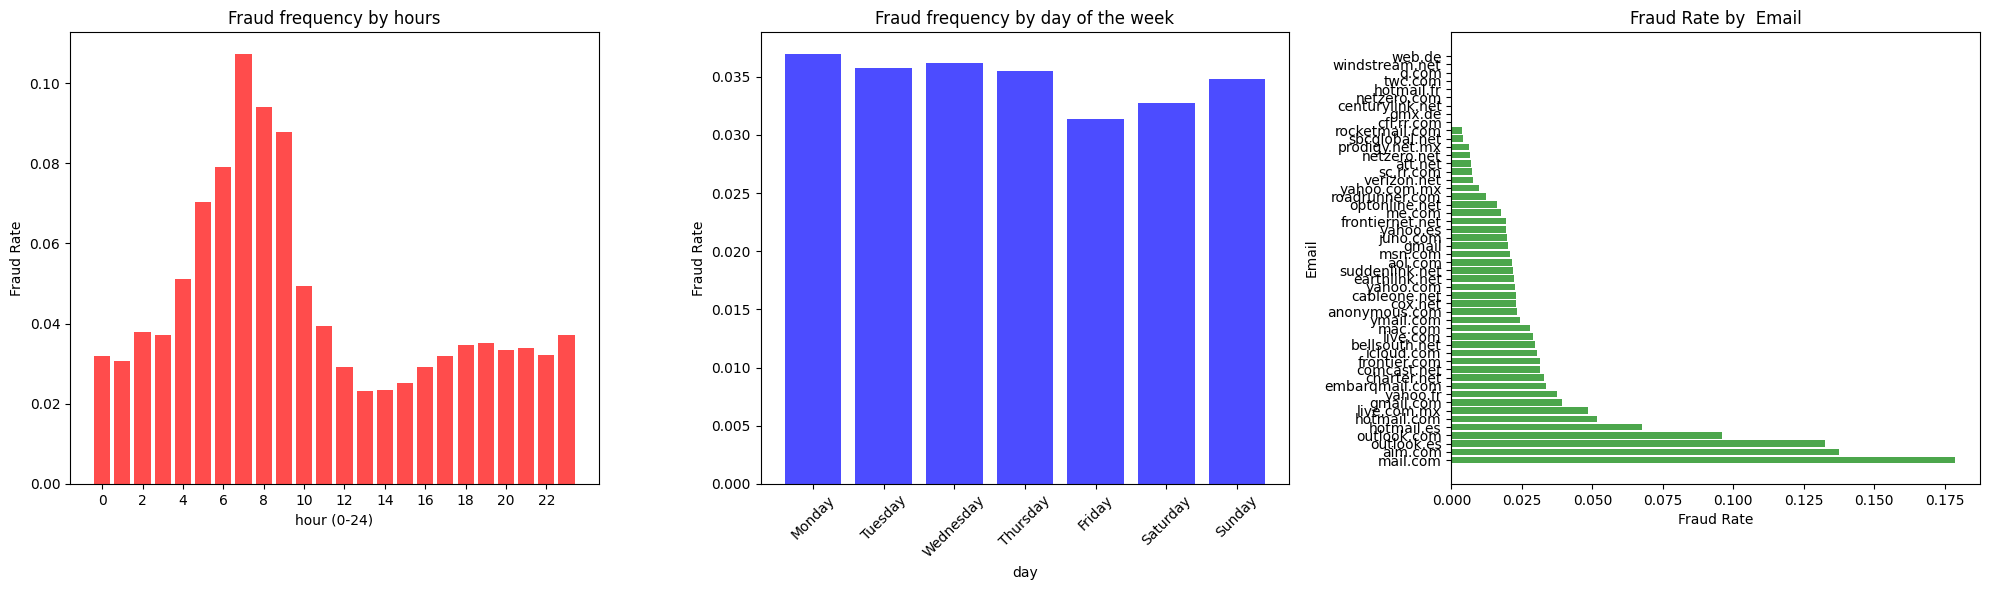

In [65]:
fig, axes= pp.subplots(1,3, figsize=(20,6))
tmp = X_train[['Transaction_hour', 'Transaction_day', 'P_emaildomain']].copy()
tmp['isFraud']=Y_train.values

hour_fraud=tmp.groupby('Transaction_hour')['isFraud'].mean()
axes[0].bar(hour_fraud.index, hour_fraud.values, color='red', alpha=0.7)
axes[0].set_title('Fraud frequency by hours')
axes[0].set_xlabel('hour (0-24)')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_xticks(range(0, 24, 2))


day_fraud=tmp.groupby('Transaction_day')['isFraud'].mean()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1].bar(range(len(day_fraud)), day_fraud.values, color='blue', alpha=0.7)
axes[1].set_title('Fraud frequency by day of the week')
axes[1].set_xlabel('day')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, rotation=45)

email_fraud=tmp.groupby('P_emaildomain')['isFraud'].agg(['mean', 'count'])
email_fraud = email_fraud[email_fraud['count'] > 100].sort_values('mean', ascending=False)

axes[2].barh(email_fraud.index, email_fraud['mean'], color='green', alpha=0.7)
axes[2].set_title('Fraud Rate by  Email')
axes[2].set_xlabel('Fraud Rate')
axes[2].set_ylabel('Email')


pp.tight_layout()
pp.savefig('fraud_analysis.png')
pp.show()

In [82]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"amount_of_cat_cols: {len(cat_cols)}")
print(f"cols: {cat_cols}")


amount_of_cat_cols: 27
cols: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'card_det']


In [19]:
class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ohe_cols=['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
                        'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']
        self.woe_cols=['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
                        'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
                        'id_37', 'id_38', 'DeviceInfo', 'card_det']
    def fit(self, X, y=None):
        self.woe_cols_pr=[c for c in self.woe_cols if c in X.columns]
        self.ohe_cols_pr=[c for c in self.ohe_cols if c in X.columns]

        self.woe=WOEEncoder(cols=self.woe_cols_pr)
        self.woe.fit(X[self.woe_cols_pr],y)

        X_tmp = pd.get_dummies(X, columns=self.ohe_cols_pr)
        self.feature_names = X_tmp.columns 
        return self

    def transform(self, X):
        X=X.copy()
        for col in self.woe_cols_pr:
            if col not in X.columns:
                X[col] = 0
        X[self.woe_cols_pr]=self.woe.transform(X[self.woe_cols_pr])
        X=pd.get_dummies(X, columns=self.ohe_cols_pr)
        X = X.reindex(columns=self.feature_names, fill_value=0)
        X=X.fillna(0)
        return X
        
        

In [83]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

with mlflow.start_run(run_name="LogisticRegression_Feature_Engineering"):
    mlflow.set_tag("description", "converting categorical features to numeric")
    mlflow.log_param("ohe_cols", ", ".join(ohe_cols))
    mlflow.log_param("woe_cols", ", ".join(woe_cols))
    mlflow.log_metric("features_after_encoding", X_train.shape[1])
    

after WOE : 368
afte OHE: 389
🏃 View run LogisticRegression_Feature_Engineering at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/98448d7cc8ca4570b2c12dbdbed8ec3d
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


In [68]:
new_features=['TransactionAmt_log', 'P_emaildomain_freq', 'Transaction_day', 'Transaction_hour', 'card_det', 'card_det_freq', 'card1_freq', 'card2_freq', 'addr1_freq' ]
with mlflow.start_run(run_name="LogisticRegression_Feature_Engineering"):
    mlflow.log_param("new_features", ", ".join(new_features))
    mlflow.log_artifact("fraud_analysis.png")
    mlflow.log_metric("total_features", X_train.shape[1])

🏃 View run LogisticRegression_Feature_Engineering at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/807b03e6aecd4f6b8fa496481f8b865d
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


<h1>Feature Selection</h1>

In [11]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold=threshold
    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        corr_with_target = X.copy()
        corr_with_target['isFraud'] = y.values
        corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
        self.to_drop=set()
        for i in range (len(corr_matrix.columns)):
            for j in range(i +1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i,j])>  self.threshold:
                    col_i = corr_matrix.columns[i]
                    col_j = corr_matrix.columns[j]
                    if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                        self.to_drop.add(col_i)
                    else:
                        self.to_drop.add(col_j)
        return self
        

    def transform(self, X):
        return X.drop(columns=[c for c in self.to_drop if c in X.columns])


    

In [84]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.90
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

to_delete: 159
{'V11', 'V183', 'V177', 'C10', 'V219', 'V133', 'V270', 'C1', 'V57', 'V297', 'V236', 'V278', 'V321', 'V198', 'V39', 'V193', 'V94', 'C8', 'V54', 'M7_T', 'V42', 'V304', 'V84', 'V295', 'M1_F', 'M6_T', 'V91', 'V238', 'V80', 'V269', 'M5_F', 'V306', 'V303', 'V317', 'V30', 'V71', 'V279', 'V251', 'V186', 'V294', 'V200', 'V93', 'V76', 'V206', 'V51', 'V69', 'V73', 'V49', 'V113', 'V127', 'V28', 'V129', 'V178', 'C14', 'V176', 'V134', 'V196', 'V31', 'V180', 'V237', 'V32', 'V105', 'V231', 'V211', 'V36', 'V212', 'V217', 'V21', 'V253', 'V255', 'V254', 'M2_F', 'V101', 'V90', 'TransactionDT', 'V44', 'V102', 'V19', 'C5', 'V33', 'V207', 'D2', 'V248', 'V319', 'M3_T', 'V224', 'V179', 'V202', 'V190', 'V128', 'V59', 'V311', 'V50', 'V97', 'M8_T', 'card6_debit', 'V106', 'V17', 'V104', 'V229', 'V218', 'C7', 'C4', 'V13', 'V273', 'V34', 'V192', 'V70', 'V299', 'V276', 'V95', 'V308', 'V318', 'V92', 'V300', 'V58', 'V64', 'V316', 'V213', 'V72', 'V242', 'V275', 'id_29', 'id_17', 'V15', 'M9_F', 'V126', 'V2

In [26]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.70
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

to_delete: 259
{'V11', 'V66', 'V79', 'C10', 'V177', 'V133', 'V130', 'C1', 'V57', 'V171', 'V137', 'V297', 'V236', 'V219', 'V321', 'V261', 'V270', 'V187', 'V198', 'V39', 'V193', 'V205', 'V94', 'V278', 'C8', 'V288', 'V302', 'V54', 'M7_T', 'V100', 'M2_F', 'V42', 'id_16', 'V189', 'V7', 'V304', 'V84', 'V295', 'V277', 'M1_F', 'M6_T', 'V91', 'V238', 'V80', 'V25', 'V269', 'V258', 'V234', 'V292', 'M5_F', 'V306', 'V172', 'V81', 'V317', 'V303', 'V125', 'V30', 'V71', 'V279', 'V244', 'V285', 'V185', 'V251', 'V227', 'V186', 'V43', 'V294', 'V200', 'card3', 'V263', 'V87', 'V93', 'V76', 'V206', 'V51', 'V69', 'V73', 'V49', 'V201', 'V214', 'V310', 'V113', 'V127', 'V116', 'V28', 'id_35', 'V129', 'V178', 'C14', 'V109', 'V176', 'V134', 'V307', 'V196', 'V31', 'V180', 'V27', 'V131', 'V237', 'V32', 'V2', 'V105', 'V231', 'V211', 'V36', 'V212', 'V217', 'V21', 'V40', 'V255', 'V253', 'V230', 'V254', 'V243', 'V101', 'V296', 'V195', 'V90', 'TransactionDT', 'V115', 'V99', 'V44', 'V102', 'V19', 'C5', 'TransactionAmt_lo

In [70]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.85
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

to_delete: 193
{'V70', 'V306', 'V265', 'V4', 'V131', 'V30', 'C11', 'V119', 'V196', 'V188', 'V64', 'V79', 'V135', 'V102', 'V42', 'V218', 'V236', 'V31', 'V177', 'V178', 'V296', 'V104', 'V113', 'V71', 'V207', 'V183', 'M8_T', 'V61', 'V58', 'V92', 'V69', 'V253', 'V39', 'V200', 'V101', 'V51', 'V291', 'V302', 'V246', 'V242', 'V13', 'V193', 'V180', 'V97', 'V167', 'V105', 'card4_visa', 'V294', 'V231', 'V93', 'V304', 'M7_T', 'V313', 'V87', 'C5', 'V261', 'V272', 'V84', 'V214', 'V204', 'V264', 'V227', 'V192', 'V229', 'V90', 'V213', 'V203', 'V95', 'V293', 'V36', 'V273', 'V321', 'V37', 'V251', 'V303', 'M6_T', 'V279', 'V96', 'V269', 'V319', 'V60', 'V274', 'V19', 'V22', 'M4_M2', 'V106', 'V49', 'V11', 'V248', 'V126', 'C4', 'C1', 'C6', 'V128', 'V44', 'V72', 'V133', 'V219', 'V270', 'D2', 'V57', 'V85', 'V103', 'V245', 'V221', 'V94', 'V168', 'V59', 'M9_F', 'V238', 'V73', 'V186', 'V255', 'V278', 'C8', 'V202', 'V179', 'V299', 'V191', 'V254', 'V16', 'V259', 'V198', 'V243', 'id_17', 'V54', 'TransactionDT', 'V3

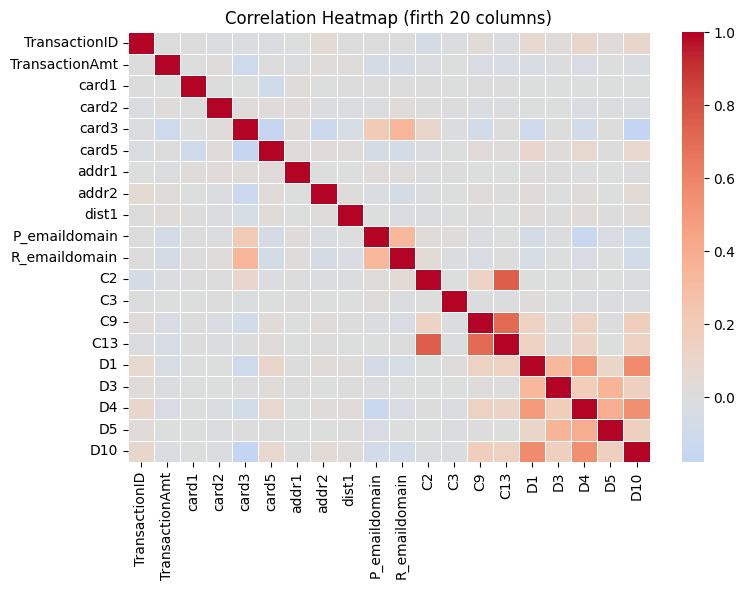

In [85]:
import seaborn as sns
cols_to_show=X_train.columns[:20]
corr_sbst=X_train[cols_to_show].corr()
pp.figure(figsize=(8, 6))
sns.heatmap(
    corr_sbst,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
pp.title('Correlation Heatmap (firth 20 columns)')
pp.tight_layout()
pp.savefig('correlation_heatmap.png')
pp.show()

In [51]:
with mlflow.start_run(run_name="Logistic_regression_Feature_selection"):
    mlflow.set_tag("description", "counting correlation to each other")
    mlflow.log_param("corr_threshold", 0.90)
    mlflow.log_metric("removed_features", len(to_drop))
    mlflow.log_metric("remaining_features", X_train.shape[1])
    #mlflow.log_artifact('correlation_heatmap.png')

🏃 View run Logistic_regression_Feature_selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/ff4782f86b584fb3bf1b234f51c46a2a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


In [12]:
class IVFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold=threshold
    def fit(self, X, y=None):
        iv_v=sc.iv(X.join(pd.Series(y, name='isFraud')), y='isFraud')
        self.weak_iv=iv_v[iv_v['info_value']<self.threshold]['variable'].tolist()
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.weak_iv if c in X.columns])
        

In [133]:
!pip install scorecardpy --quiet
import scorecardpy as sc
iv_v=sc.iv(X_train.join(Y_train), y='isFraud')
threshold_iv=0.05
weak_iv=iv_v[iv_v['info_value']<threshold_iv]['variable'].tolist()

iv_sorted = iv_v.sort_values('info_value', ascending=True).tail(20)


pp.figure(figsize=(10, 8))
pp.barh(iv_sorted['variable'], iv_sorted['info_value'], 
         color=pp.cm.viridis([x/iv_sorted['info_value'].max() 
                               for x in iv_sorted['info_value']]))
pp.title('Feature Predictive Power (Information Value)')
pp.xlabel('Information Value')
pp.axvline(x=0.05, color='red', linestyle='--', label='threshold (0.05)')
pp.legend()
pp.tight_layout()
pp.savefig('iv_plot.png')
pp.show()

print(f"weak_iv_cols: {len(weak_iv)}")
X_train=X_train.drop(columns=weak_iv)
X_val=X_val.drop(columns=weak_iv)
print(f"left_cols: {X_train.shape[1]}")

KeyboardInterrupt: 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behav

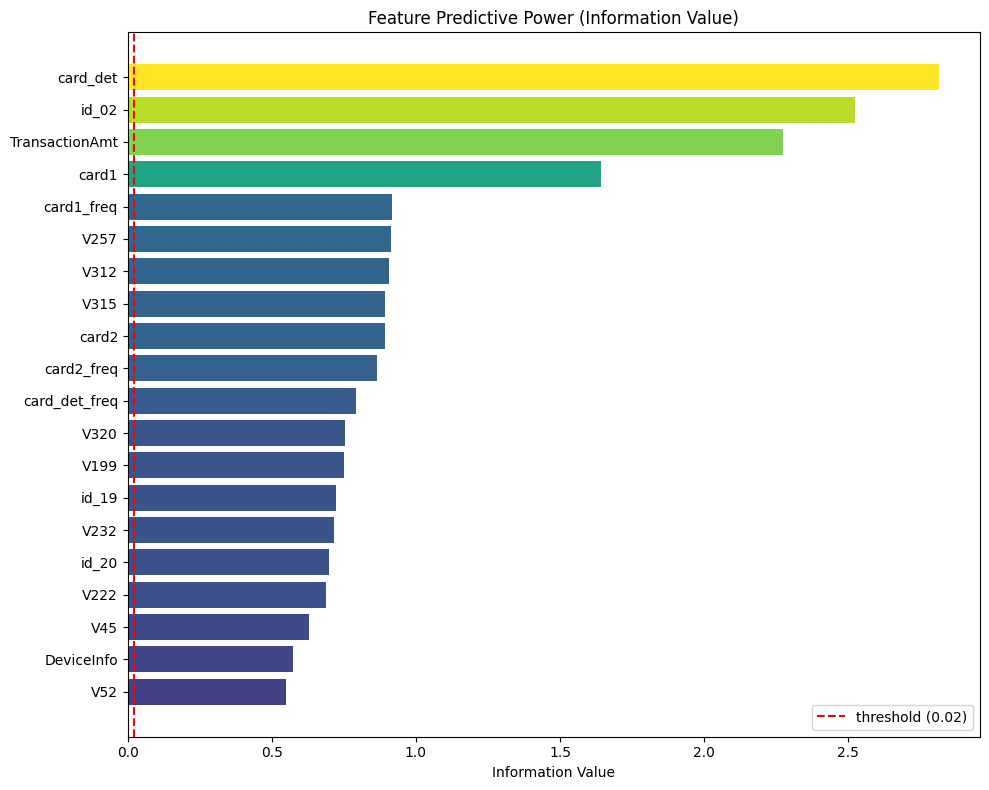

weak_iv_cols: 38
left_cols: 92


In [27]:
!pip install scorecardpy --quiet
import scorecardpy as sc
iv_v=sc.iv(X_train.join(Y_train), y='isFraud')
threshold_iv=0.02
weak_iv=iv_v[iv_v['info_value']<threshold_iv]['variable'].tolist()

iv_sorted = iv_v.sort_values('info_value', ascending=True).tail(20)


pp.figure(figsize=(10, 8))
pp.barh(iv_sorted['variable'], iv_sorted['info_value'], 
         color=pp.cm.viridis([x/iv_sorted['info_value'].max() 
                               for x in iv_sorted['info_value']]))
pp.title('Feature Predictive Power (Information Value)')
pp.xlabel('Information Value')
pp.axvline(x=0.02, color='red', linestyle='--', label='threshold (0.02)')
pp.legend()
pp.tight_layout()
pp.savefig('iv_plot.png')
pp.show()

print(f"weak_iv_cols: {len(weak_iv)}")
X_train=X_train.drop(columns=weak_iv)
X_val=X_val.drop(columns=weak_iv)
print(f"left_cols: {X_train.shape[1]}")

In [53]:
with mlflow.start_run(run_name='Logistic_Regression_Feature_selection'):
    mlflow.set_tag("description", "counting IV")
    mlflow.log_param('IV_threshold', 0.05)
    mlflow.log_metric("removed_weak_iv_cols", len(weak_iv))
    mlflow.log_metric("remaining_cols", X_train.shape[1])
    mlflow.log_artifact('iv_plot.png')

🏃 View run Logistic_Regression_Feature_selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/2c3fc2ca904540c8992d3cc5822e7839
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


In [87]:
from sklearn.preprocessing import StandardScaler
X_train=X_train.fillna(0)
X_val=X_val.fillna(0)
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_val_scaled = scalar.transform(X_val)

In [13]:
class L1Regularisation(BaseEstimator, TransformerMixin):
    def __init__(self, C=0.01):
        self.C=C
    def fit(self, X, y=None):
        lr_l1 = LogisticRegression(
            penalty='l1',
            C=0.01,
            solver='saga',
            max_iter=1000,
            n_jobs=-1,
            random_state=42
        )
        lr_l1.fit(X,y)
        self.mask = lr_l1.coef_[0] != 0
        return self
        
    def transform(self, X):
        return X[:, self.mask]
        

In [123]:
from sklearn.linear_model import LogisticRegression
#scalar = StandardScaler()
#X_train_scaled=scalar.fit_transform(X_train)
#X_val_scaled=scalar.transform(X_val)
lr_l1 = LogisticRegression(
    penalty='l1',
    C=0.01,
    solver='saga',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)
lr_l1.fit(X_train_scaled, Y_train)

selected_cols = X_train.columns[lr_l1.coef_[0] != 0].tolist()
print(f"columns selected by L1: {len(selected_cols)}")

X_train=X_train[selected_cols]
X_val=X_val[selected_cols]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 433 but size of corresponding boolean axis is 165

In [64]:
with mlflow.start_run(run_name="Logistic_Regression_Feature_Selection"):
    mlflow.set_tag("description", "we choose  best columns by  L1 Regularization")
    mlflow.log_param("C", 0.01)
    mlflow.log_param("penalty", "l1")
    mlflow.log_metric("selected_features", len(selected_cols))

🏃 View run Logistic_Regression_Feature_Selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/218223954a8e4ec3b83b48ff1aff2318
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


<h1>Training</h1>

roc_auc_val: 0.8823
roc_auc_train: 0.8949
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    113866
           1       0.86      0.30      0.45      4242

    accuracy                           0.97    118108
   macro avg       0.92      0.65      0.72    118108
weighted avg       0.97      0.97      0.97    118108



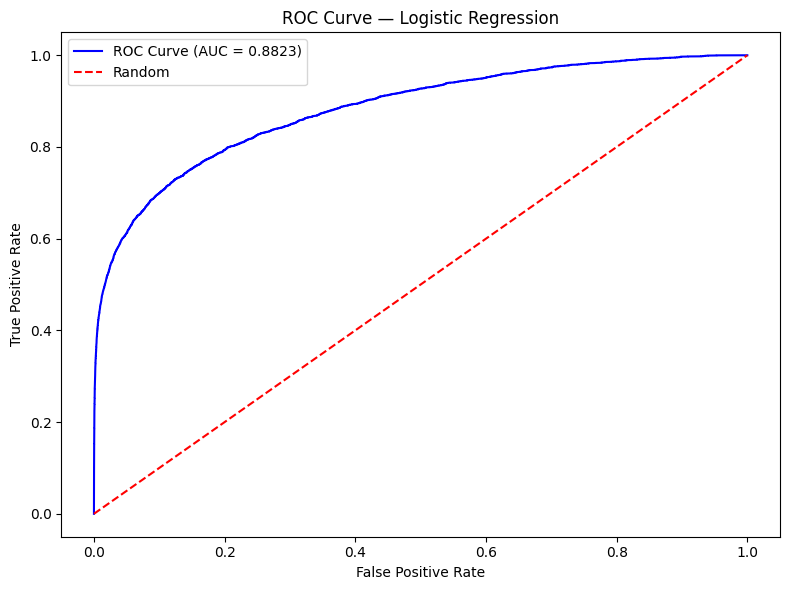

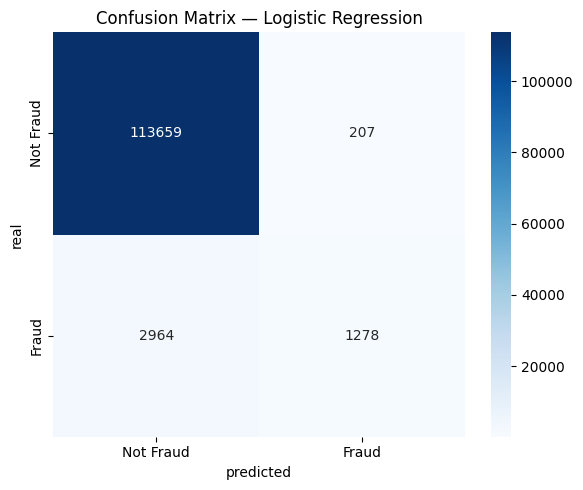

In [89]:
import seaborn as sns
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
Y_pred_prob=lr_l1.predict_proba(X_val_scaled)[:, 1]
Y_pred=lr_l1.predict(X_val_scaled)
Y_train_prob = lr_l1.predict_proba(X_train_scaled)[:, 1]

roc_auc_val=roc_auc_score(Y_val,Y_pred_prob)
roc_auc_train = roc_auc_score(Y_train, Y_train_prob)
print(f"roc_auc_val: {roc_auc_val:.4f}")
print(f"roc_auc_train: {roc_auc_train:.4f}")
print(classification_report(Y_val, Y_pred))
fpr_val, tpr_val, _ = roc_curve(Y_val, Y_pred_prob)
fpr_train, tpr_train, _ = roc_curve(Y_train, Y_train_prob)
pp.figure(figsize=(8, 6))
pp.plot(fpr_val, tpr_val, color='blue', label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
pp.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random')
pp.title('ROC Curve — Logistic Regression')
pp.xlabel('False Positive Rate')
pp.ylabel('True Positive Rate')
pp.legend()
pp.tight_layout()
pp.savefig('roc_curve.png')
pp.show()

cm = confusion_matrix(Y_val, Y_pred)
pp.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
pp.title('Confusion Matrix — Logistic Regression')
pp.ylabel('real')
pp.xlabel('predicted')
pp.tight_layout()
pp.savefig('confusion_matrix.png')
pp.show()

In [90]:
with mlflow.start_run(run_name="Logistic_Regression_Training"):
    mlflow.set_tag("description", "Logistic Regression L1, C=0.01, ROC-AUC")
    mlflow.log_param("null_threshold", 0.80)
    mlflow.log_param("corr_threshold", 0.90)
    mlflow.log_param("IV_threshold", 0.05)
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("C", 0.01)
    mlflow.log_param("solver", "saga")
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("selected_features", len(selected_cols))
    mlflow.log_artifact("roc_curve.png")
    mlflow.log_artifact("confusion_matrix.png")


🏃 View run Logistic_Regression_Training at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/41a6e51029fd422c980e612365023a8f
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0


In [20]:
from sklearn.pipeline import Pipeline
full_pipeline=Pipeline([
    ('null_dropper', NULLDropperThreshold(threshold=0.80)),
    ('filler', NULLFiller()),
    ('new_cols_add',NewColsAdd()),
    ('encoder', Encoder()),
    ('correlation', CorrelationFilter(threshold=0.90)),
    ('iv', IVFilter(threshold=0.05)),
    ('scalar', StandardScaler()),
    ('L1Regularisation', L1Regularisation(C=0.01)),
    ('model', LogisticRegression(
        penalty='l1', C=0.01, solver='saga',
        max_iter=1000, n_jobs=-1, random_state=42
    ))                      
])
                        

In [21]:
full_pipeline.fit(X_train_raw,Y_train)
y_pred_proba = full_pipeline.predict_proba(X_val_raw)[:, 1]
roc_auc_val = roc_auc_score(Y_val, y_pred_proba)
y_train_proba = full_pipeline.predict_proba(X_train_raw)[:, 1]
roc_auc_train = roc_auc_score(Y_train, y_train_proba)
print(f"Pipeline ROC-AUC: {roc_auc_val:.4f}")

/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behav

Pipeline ROC-AUC: 0.8823


In [22]:
with mlflow.start_run(run_name="Logistic_Regression_Pipeline"):
    mlflow.sklearn.log_model(full_pipeline, "Logistic_Regression_pipeline")
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("overfit_gap", roc_auc_train - roc_auc_val)
    mlflow.log_param("C", 0.01)
    mlflow.log_param("corr_th", 0.90)
    mlflow.log_param("IV_th", 0.05)
    mlflow.log_param("null_th", 0.80)
    
    
       
    

2026/05/05 21:15:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 21:15:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic_Regression_Pipeline at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0/runs/175b9c1d1736450ca5bebef3e7edc0ce
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/0
